<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/agentic_neqsim_workflow_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agentic process simulation with NeqSim

This notebook shows how an engineering script or AI agent can discover a NeqSim flowsheet,
change bounded operating variables, run the calculation, collect structured validation evidence,
reject unsafe candidates, and return a reproducible JSON result.

## Audience, prerequisites, and learning objectives

**Audience.** Process engineers, simulation engineers, data scientists, and developers building
tool-using engineering agents. Readers should know basic Python and steady-state process
simulation.

**Prerequisites.** A Google Colab or Jupyter runtime with internet access for the first package
installation.

After completing the notebook, you can:

1. define a process case as data rather than hidden notebook state;
2. build a rich-gas compression, cooling, and separation flowsheet;
3. discover units, variables, ports, and adjustable parameters through `ProcessAutomation`;
4. use safe string-addressed reads and writes with structured diagnostics;
5. execute atomic setpoint-run-readback trials through `evaluate`;
6. validate mass, component, compressor-energy, and cooler-energy closure;
7. screen an operating envelope and reject infeasible candidates; and
8. run the native `AgenticProcessOptimizer` with a replayable JSON trajectory.

## Reproducible Colab setup

The setup cell installs the latest public PyPI package only when NeqSim is absent. It does not
use a local checkout, unpublished wheel, manually injected JAR, hidden file, or runtime restart.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )

In [2]:
import json
import math
import os
import platform
import subprocess
from importlib.metadata import version

os.environ.setdefault(
    "MPLCONFIGDIR",
    "/tmp/neqsim-agentic-matplotlib",
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from jpype import JClass

from neqsim import jneqsim

NEQSIM_VERSION = version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_VERSION = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "red": "#D55E00",
    "gray": "#666666",
}
plt.style.use("seaborn-v0_8-whitegrid")

print(f"NeqSim: {NEQSIM_VERSION}")
print(f"Python: {PYTHON_VERSION}")
print(f"Java: {JAVA_VERSION}")

NeqSim: 3.16.0
Python: 3.12.13
Java: openjdk version "17.0.19" 2026-04-21


## Preservation inventory

The original placeholder contained four substantive teaching intentions:

1. a reusable `make_gas` fluid-construction function;
2. a structured case dictionary;
3. a `Stream`-`Compressor`-`ProcessSystem` calculation; and
4. a JSON-style result object consumed as a pandas table.

All four are preserved and expanded below. The original imported plotting libraries but produced
no figure, so there is no previous technical figure to preserve or numerically refresh. Five new
figures are added for workflow, baseline performance, scenario response, operating-envelope
screening, and optimizer trajectory.

## Engineering context

An agent should not guess Java methods, silently mutate an object graph, or accept a simulation
merely because it returned a number. NeqSim's `ProcessAutomation` facade exposes stable string
addresses, discoverable inputs and outputs, safe diagnostics, and schema-versioned run feedback.

The engineering application is a rich-gas conditioning train:

`feed gas -> export compressor -> aftercooler -> cold separator`

Compression raises pressure and temperature. Cooling removes heat and condenses heavy
hydrocarbons. The separator produces export gas and hydrocarbon liquid. The agent must balance
compressor power against a minimum liquid-recovery target while respecting bounded setpoints.

## Governing relationships

For steady flow, the compressor power should equal the enthalpy rise:

$$
\dot{W}_{c} = \dot{m}\left(h_{2}-h_{1}\right)
$$

The cooler duty is

$$
\dot{Q}_{cool} = \dot{m}\left(h_{3}-h_{2}\right)
$$

where $\dot{m}$ is mass flow in kg/s, $h$ is specific enthalpy in J/kg, $\dot{W}_{c}$ is
compressor power in W, and $\dot{Q}_{cool}$ is negative when heat leaves the process.

The separator mass balance is

$$
\dot{m}_{feed} = \dot{m}_{gas} + \dot{m}_{liquid}
$$

The agent accepts a trial only when the run succeeds, every requested setpoint is applied, and
all required readbacks are available.

## Model assumptions and validity limits

The fluid is a documented synthetic rich gas. Component values are mole fractions and sum to
one. The Soave-Redlich-Kwong equation of state with the classic mixing rule is used for
hydrocarbon screening. The model assumes steady state, adiabatic compression apart from the
specified efficiency, equilibrium cooling and separation, and no pressure drop in the cooler or
separator.

This is an educational operating-screening example. It does not include compressor maps,
anti-surge control, hydrate or wax checks, mechanical limits, relief design, dynamic inventory,
or uncertainty in feed characterization.

## Preserve the case-as-data pattern

The original case dictionary is retained and expanded with explicit efficiency, cooler
temperature, composition, and an agent decision policy. Every pressure is absolute in bara,
temperature is in degrees Celsius, and mass flow is in kg/h.

In [3]:
CASE = {
    "name": "rich-gas conditioning",
    "feed_temperature_C": 25.0,
    "feed_pressure_bara": 55.0,
    "feed_flow_kg_per_hr": 10000.0,
    "compressor_outlet_pressure_bara": 100.0,
    "compressor_isentropic_efficiency": 0.78,
    "aftercooler_outlet_temperature_C": 5.0,
    "minimum_liquid_flow_kg_per_hr": 2165.0,
    "pressure_bounds_bara": [75.0, 115.0],
    "composition_mole_fraction": {
        "nitrogen": 0.005,
        "CO2": 0.015,
        "methane": 0.775,
        "ethane": 0.090,
        "propane": 0.060,
        "n-butane": 0.030,
        "n-pentane": 0.015,
        "n-hexane": 0.010,
    },
}

display(pd.DataFrame([CASE]).drop(columns=["composition_mole_fraction"]))

,name,feed_temperature_C,feed_pressure_bara,feed_flow_kg_per_hr,compressor_outlet_pressure_bara,compressor_isentropic_efficiency,aftercooler_outlet_temperature_C,minimum_liquid_flow_kg_per_hr,pressure_bounds_bara
0,rich-gas conditioning,25.0,55.0,10000.0,100.0,0.78,5.0,2165.0,"[75.0, 115.0]"


In [4]:
composition_table = pd.DataFrame(
    {
        "component": list(CASE["composition_mole_fraction"]),
        "mole fraction [-]": list(
            CASE["composition_mole_fraction"].values()
        ),
    }
)
composition_sum = composition_table["mole fraction [-]"].sum()

display(composition_table)
print(f"Composition sum: {composition_sum:.12f}")

Composition sum: 1.000000000000


,component,mole fraction [-]
0,nitrogen,0.005
1,CO2,0.015
2,methane,0.775
3,ethane,0.090
4,propane,0.060
5,n-butane,0.030
6,n-pentane,0.015
7,n-hexane,0.010


## Fluid representation in NeqSim

`SystemSrkEos` stores composition, temperature, pressure, and the thermodynamic model.
`setMultiPhaseCheck(True)` allows equilibrium liquid to appear. A fresh fluid is built for each
independent process so scenario results do not depend on an earlier notebook state.

In [5]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Separator = jneqsim.process.equipment.separator.Separator
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def make_gas(case_data):
    temperature_k = case_data["feed_temperature_C"] + 273.15
    pressure_bara = case_data["feed_pressure_bara"]
    fluid = SystemSrkEos(temperature_k, pressure_bara)

    for component_name, mole_fraction in (
        case_data["composition_mole_fraction"].items()
    ):
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid

## Build a composable process

Named streams and equipment are important because automation addresses include unit names. The
function returns both the `ProcessSystem` and its units so normal engineering calculations and
agent-facing automation can be validated against each other.

In [6]:
def build_process(case_data):
    fluid = make_gas(case_data)

    feed = Stream("Feed gas", fluid)
    feed.setFlowRate(
        case_data["feed_flow_kg_per_hr"],
        "kg/hr",
    )
    feed.setTemperature(
        case_data["feed_temperature_C"],
        "C",
    )
    feed.setPressure(
        case_data["feed_pressure_bara"],
        "bara",
    )

    compressor = Compressor("Export compressor", feed)
    compressor.setOutletPressure(
        case_data["compressor_outlet_pressure_bara"],
        "bara",
    )
    compressor.setIsentropicEfficiency(
        case_data["compressor_isentropic_efficiency"]
    )

    aftercooler = Cooler(
        "Aftercooler",
        compressor.getOutletStream(),
    )
    aftercooler.setOutTemperature(
        case_data["aftercooler_outlet_temperature_C"] + 273.15
    )

    separator = Separator(
        "Cold separator",
        aftercooler.getOutletStream(),
    )

    process = ProcessSystem()
    for unit in (feed, compressor, aftercooler, separator):
        process.add(unit)

    return {
        "process": process,
        "feed": feed,
        "compressor": compressor,
        "aftercooler": aftercooler,
        "separator": separator,
    }

## Baseline execution

`getAutomation()` returns the cached facade for this process. `runJson()` executes the flowsheet
and returns structured success information rather than a `void` result that an agent might
misinterpret.

In [7]:
baseline = build_process(CASE)
automation = baseline["process"].getAutomation()
baseline_run_status = json.loads(str(automation.runJson()))

display(pd.json_normalize(baseline_run_status))

,schemaVersion,completed,success,failedUnitName,failedUnitError,unitCount,units
0,1.0,True,True,None,None,4,"[{'unitName': 'Feed gas', 'unitType': 'Stream'..."


## Figure 1 — workflow overview

The diagram is generated locally from the actual unit names. It shows the reusable chain from
case data to validated result, not a decorative process illustration.

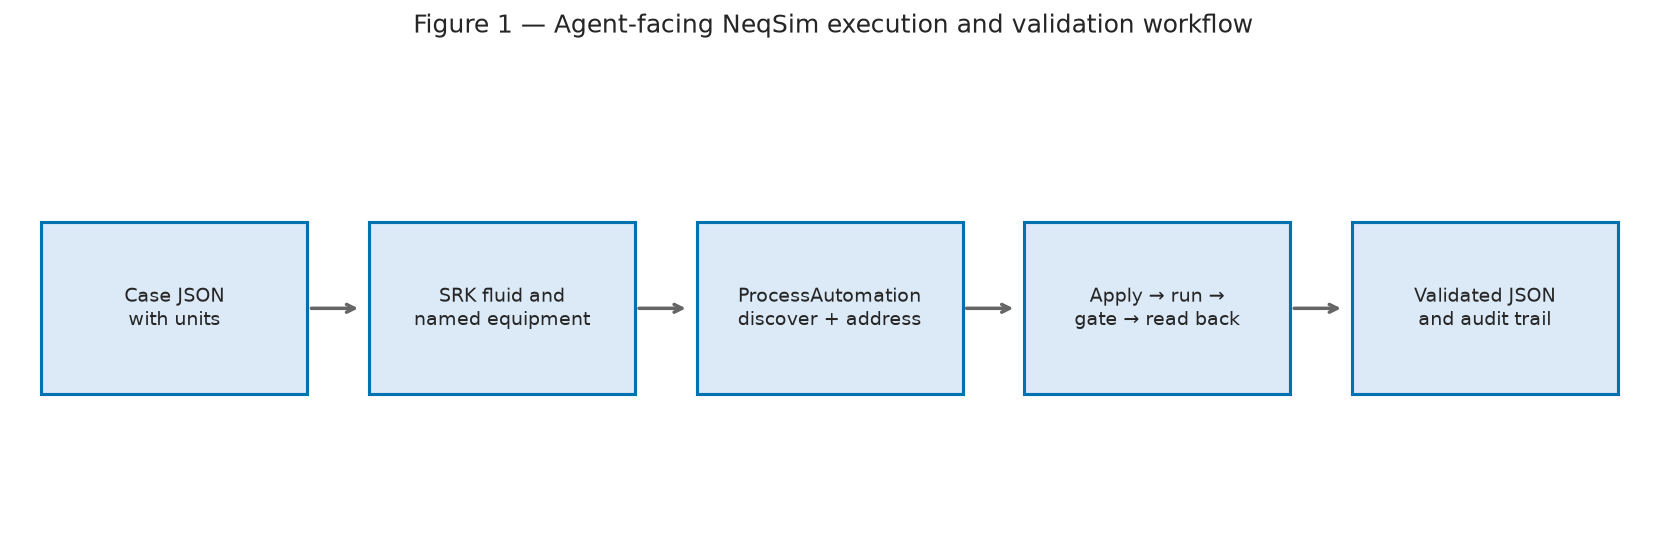

In [8]:
fig, ax = plt.subplots(figsize=(12, 4.0))
ax.set_xlim(0.0, 12.0)
ax.set_ylim(0.0, 4.0)
ax.axis("off")

workflow_boxes = [
    (0.2, "Case JSON\nwith units"),
    (2.6, "SRK fluid and\nnamed equipment"),
    (5.0, "ProcessAutomation\ndiscover + address"),
    (7.4, "Apply → run →\ngate → read back"),
    (9.8, "Validated JSON\nand audit trail"),
]

for x_position, label in workflow_boxes:
    box = plt.Rectangle(
        (x_position, 1.15),
        1.95,
        1.45,
        facecolor="#DCEAF7",
        edgecolor=COLORS["blue"],
        linewidth=1.6,
    )
    ax.add_patch(box)
    ax.text(
        x_position + 0.975,
        1.875,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

for x_position in (2.15, 4.55, 6.95, 9.35):
    ax.annotate(
        "",
        xy=(x_position + 0.4, 1.875),
        xytext=(x_position, 1.875),
        arrowprops={
            "arrowstyle": "->",
            "color": COLORS["gray"],
            "lw": 1.8,
        },
    )

ax.set_title(
    "Figure 1 — Agent-facing NeqSim execution and validation workflow",
    fontsize=13,
    pad=12,
)
plt.tight_layout()
plt.show()

The workflow keeps engineering authority outside the language model: NeqSim performs the
thermodynamics, the automation layer validates addresses and run status, and explicit checks
decide whether results are acceptable.

## Discover units and variables

An agent should inspect the available surface before issuing a write. `getUnitList()` and
`getVariableList()` expose stable addresses, variable types, default units, and descriptions.

In [9]:
unit_names = list(automation.getUnitList())
variable_rows = []

for unit_name in unit_names:
    for variable in automation.getVariableList(unit_name):
        variable_rows.append(
            {
                "unit": str(unit_name),
                "address": str(variable.getAddress()),
                "type": str(variable.getType().toString()),
                "default unit": str(variable.getDefaultUnit()),
                "description": str(variable.getDescription()),
            }
        )

variable_catalog = pd.DataFrame(variable_rows)

print(f"Discovered units: {unit_names}")
print(f"Discovered variables: {len(variable_catalog)}")
display(variable_catalog)

Discovered units: ['Feed gas', 'Export compressor', 'Aftercooler', 'Cold separator']
Discovered variables: 42


,unit,address,type,default unit,description
0,Feed gas,Feed gas.temperature,OUTPUT,K,Equipment temperature
1,Feed gas,Feed gas.pressure,OUTPUT,bara,Equipment pressure
2,Feed gas,Feed gas.temperature,INPUT,K,Stream temperature
3,Feed gas,Feed gas.pressure,INPUT,bara,Stream pressure
4,Feed gas,Feed gas.flowRate,INPUT,kg/hr,Stream mass flow rate
5,Feed gas,Feed gas.density,OUTPUT,kg/m3,Stream density
6,Feed gas,Feed gas.molarMass,OUTPUT,kg/mol,Stream molar mass
7,Export compressor,Export compressor.temperature,OUTPUT,K,Equipment temperature
8,Export compressor,Export compressor.pressure,OUTPUT,bara,Equipment pressure
9,Export compressor,Export compressor.outletPressure,INPUT,bara,Compressor outlet pressure


## Topology and adjustable parameters

`getTopology()` explains connections and ports. `getAdjustableParametersJson()` supplies a
machine-readable action space with bounds. Bounds are generic API bounds, so an engineering
agent must still apply narrower case-specific limits.

In [10]:
topology = json.loads(str(automation.getTopology()))
adjustable_parameters = json.loads(
    str(automation.getAdjustableParametersJson())
)

topology_table = pd.DataFrame(topology["equipment"])
adjustable_table = pd.DataFrame(
    adjustable_parameters["parameters"]
)

display(topology_table)
display(adjustable_table)

,name,type,inlets,outlets
0,Feed gas,Stream,[],[]
1,Export compressor,Compressor,[Feed gas],[Export compressor out stream]
2,Aftercooler,Cooler,[Export compressor out stream],[outStream]
3,Cold separator,Separator,[outStream],"[gasOutStream, liquidOutStream]"


,name,address,unit,lowerBound,upperBound,targetUnitName,targetProperty,source
0,temperature,Feed gas.temperature,K,1.000000,2000.0,Feed gas,temperature,INPUT_VARIABLE
1,pressure,Feed gas.pressure,bara,0.000001,10000.0,Feed gas,pressure,INPUT_VARIABLE
2,flowRate,Feed gas.flowRate,kg/hr,0.000000,NaN,Feed gas,flowRate,INPUT_VARIABLE
3,outletPressure,Export compressor.outletPressure,bara,0.000001,10000.0,Export compressor,outletPressure,INPUT_VARIABLE
4,polytropicEfficiency,Export compressor.polytropicEfficiency,,0.000000,1.0,Export compressor,polytropicEfficiency,INPUT_VARIABLE
5,speed,Export compressor.speed,rpm,0.000000,NaN,Export compressor,speed,INPUT_VARIABLE
6,outletTemperature,Aftercooler.outletTemperature,C,1.000000,2000.0,Aftercooler,outletTemperature,INPUT_VARIABLE


## Self-healing reads and explicit diagnostics

The next call intentionally misspells `compressor`. The safe accessor returns JSON and
auto-corrects the address instead of terminating the workflow. Production systems should log the
correction and continue only when it is unambiguous.

In [11]:
safe_read = json.loads(
    str(
        automation.getVariableValueSafe(
            "Export compresor.power",
            "kW",
        )
    )
)

display(pd.json_normalize(safe_read))

,status,address,value,unit
0,success,Export compresor.power,199.147529,kW


## Preserve and strengthen the result object

The original notebook returned inputs, two key results, and boolean validation. The expanded
schema preserves that pattern while adding version provenance, run status, product flows,
equipment duties, and the exact automation surface used.

In [12]:
separator = baseline["separator"]
compressor = baseline["compressor"]
aftercooler = baseline["aftercooler"]

baseline_results = {
    "schema_version": "1.0",
    "case_name": CASE["name"],
    "provenance": {
        "neqsim_version": NEQSIM_VERSION,
        "python_version": PYTHON_VERSION,
        "java_version": JAVA_VERSION,
        "thermodynamic_model": "SRK",
        "mixing_rule": "classic",
    },
    "inputs": {
        key: value
        for key, value in CASE.items()
        if key != "composition_mole_fraction"
    },
    "key_results": {
        "compressor_power_kW": float(compressor.getPower("kW")),
        "compressor_outlet_temperature_C": float(
            compressor.getOutletStream().getTemperature("C")
        ),
        "aftercooler_duty_kW": float(aftercooler.getDuty()) / 1000.0,
        "gas_product_kg_per_hr": float(
            separator.getGasOutStream().getFlowRate("kg/hr")
        ),
        "liquid_product_kg_per_hr": float(
            separator.getLiquidOutStream().getFlowRate("kg/hr")
        ),
    },
    "validation": {
        "run_succeeded": baseline_run_status["success"],
        "setpoint_contract_discoverable": (
            adjustable_parameters["count"] > 0
        ),
    },
}

print(json.dumps(baseline_results, indent=2))
display(pd.DataFrame([baseline_results["key_results"]]))

{
  "schema_version": "1.0",
  "case_name": "rich-gas conditioning",
  "provenance": {
    "neqsim_version": "3.16.0",
    "python_version": "3.12.13",
    "java_version": "openjdk version \"17.0.19\" 2026-04-21",
    "thermodynamic_model": "SRK",
    "mixing_rule": "classic"
  },
  "inputs": {
    "name": "rich-gas conditioning",
    "feed_temperature_C": 25.0,
    "feed_pressure_bara": 55.0,
    "feed_flow_kg_per_hr": 10000.0,
    "compressor_outlet_pressure_bara": 100.0,
    "compressor_isentropic_efficiency": 0.78,
    "aftercooler_outlet_temperature_C": 5.0,
    "minimum_liquid_flow_kg_per_hr": 2165.0,
    "pressure_bounds_bara": [
      75.0,
      115.0
    ]
  },
  "key_results": {
    "compressor_power_kW": 199.14752877659086,
    "compressor_outlet_temperature_C": 64.12146088026668,
    "aftercooler_duty_kW": -585.7403624395427,
    "gas_product_kg_per_hr": 7911.721223632754,
    "liquid_product_kg_per_hr": 2088.278776367244
  },
  "validation": {
    "run_succeeded": true,
 

,compressor_power_kW,compressor_outlet_temperature_C,aftercooler_duty_kW,gas_product_kg_per_hr,liquid_product_kg_per_hr
0,199.147529,64.121461,-585.740362,7911.721224,2088.278776


## Engineering audits

The API and direct object graph must agree. The following cell checks total and component
closure across the separator plus independent enthalpy balances for compressor and cooler.

In [13]:
feed = baseline["feed"]
gas_product = separator.getGasOutStream()
liquid_product = separator.getLiquidOutStream()

feed_mass_kg_per_hr = float(feed.getFlowRate("kg/hr"))
product_mass_kg_per_hr = float(
    gas_product.getFlowRate("kg/hr")
    + liquid_product.getFlowRate("kg/hr")
)
mass_residual_kg_per_hr = (
    product_mass_kg_per_hr - feed_mass_kg_per_hr
)

component_rows = []
for component_name in CASE["composition_mole_fraction"]:
    feed_component_mol_per_s = (
        feed.getFlowRate("mole/sec")
        * feed.getFluid().getComponent(component_name).getz()
    )
    gas_component_mol_per_s = (
        gas_product.getFlowRate("mole/sec")
        * gas_product.getFluid().getComponent(component_name).getz()
    )
    liquid_component_mol_per_s = (
        liquid_product.getFlowRate("mole/sec")
        * liquid_product.getFluid().getComponent(component_name).getz()
    )
    component_rows.append(
        {
            "component": component_name,
            "feed [mol/s]": feed_component_mol_per_s,
            "products [mol/s]": (
                gas_component_mol_per_s
                + liquid_component_mol_per_s
            ),
            "residual [mol/s]": (
                gas_component_mol_per_s
                + liquid_component_mol_per_s
                - feed_component_mol_per_s
            ),
        }
    )

component_balance = pd.DataFrame(component_rows)
maximum_component_residual_mol_per_s = float(
    component_balance["residual [mol/s]"].abs().max()
)

mass_flow_kg_per_s = float(feed.getFlowRate("kg/sec"))
feed_enthalpy_j_per_kg = float(
    feed.getFluid().getEnthalpy("J/kg")
)
compressor_enthalpy_j_per_kg = float(
    compressor.getOutletStream().getFluid().getEnthalpy("J/kg")
)
cooler_enthalpy_j_per_kg = float(
    aftercooler.getOutletStream().getFluid().getEnthalpy("J/kg")
)

calculated_compressor_power_w = mass_flow_kg_per_s * (
    compressor_enthalpy_j_per_kg - feed_enthalpy_j_per_kg
)
compressor_energy_residual_w = (
    float(compressor.getPower("W"))
    - calculated_compressor_power_w
)
calculated_cooler_duty_w = mass_flow_kg_per_s * (
    cooler_enthalpy_j_per_kg - compressor_enthalpy_j_per_kg
)
cooler_energy_residual_w = (
    float(aftercooler.getDuty())
    - calculated_cooler_duty_w
)

audit_table = pd.DataFrame(
    [
        {
            "check": "total mass",
            "residual": mass_residual_kg_per_hr,
            "unit": "kg/h",
        },
        {
            "check": "maximum component",
            "residual": maximum_component_residual_mol_per_s,
            "unit": "mol/s",
        },
        {
            "check": "compressor energy",
            "residual": compressor_energy_residual_w,
            "unit": "W",
        },
        {
            "check": "cooler energy",
            "residual": cooler_energy_residual_w,
            "unit": "W",
        },
    ]
)

display(component_balance)
display(audit_table)

,component,feed [mol/s],products [mol/s],residual [mol/s]
0,nitrogen,0.623565,0.623565,0.000000e+00
1,CO2,1.870694,1.870694,2.220446e-16
2,methane,96.652529,96.652529,0.000000e+00
3,ethane,11.224165,11.224165,0.000000e+00
4,propane,7.482776,7.482776,-8.881784e-16
5,n-butane,3.741388,3.741388,4.440892e-16
6,n-pentane,1.870694,1.870694,0.000000e+00
7,n-hexane,1.247129,1.247129,0.000000e+00


,check,residual,unit
0,total mass,-1.818989e-12,kg/h
1,maximum component,8.881784e-16,mol/s
2,compressor energy,-2.910383e-11,W
3,cooler energy,0.000000e+00,W


## Figure 2 — baseline engineering result

The left panel separates power input from heat removal; the cooler duty is plotted as positive
heat removed for readability. The right panel shows the mass split. The plotted data come from
the just-completed NeqSim run.

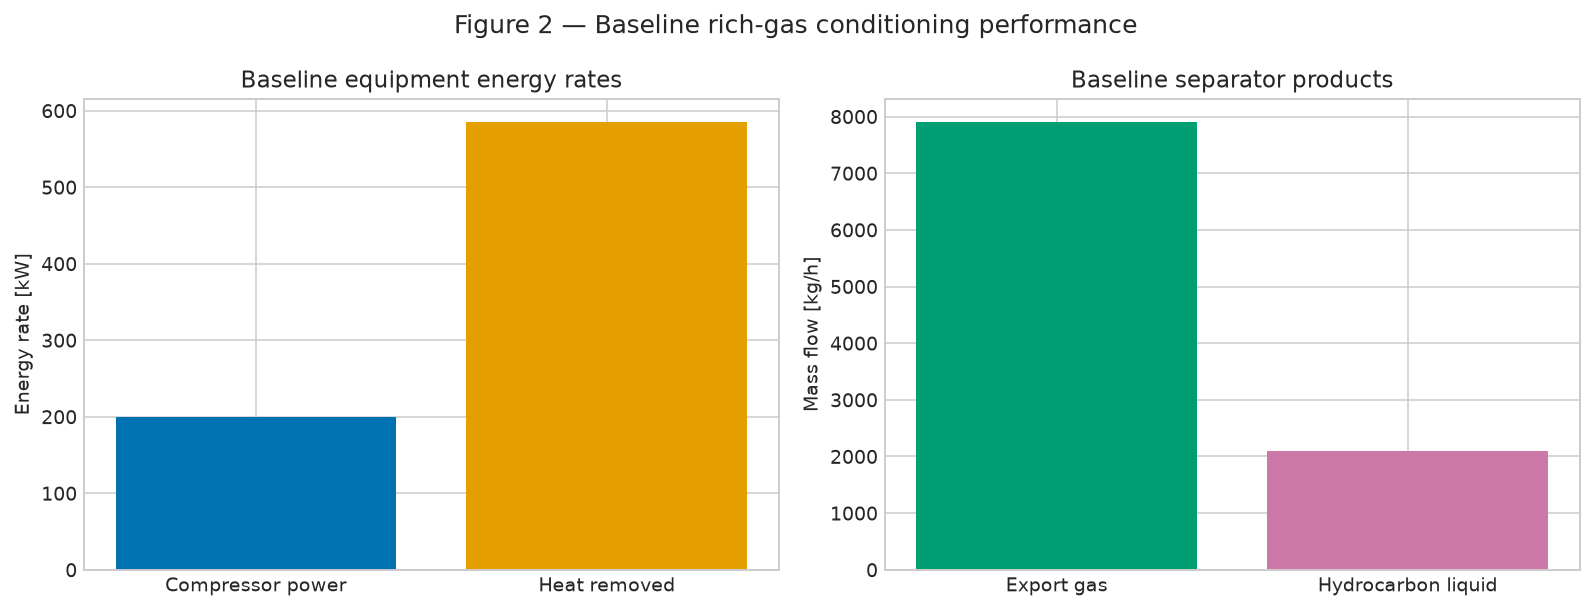

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

energy_values_kw = [
    float(compressor.getPower("kW")),
    -float(aftercooler.getDuty()) / 1000.0,
]
axes[0].bar(
    ["Compressor power", "Heat removed"],
    energy_values_kw,
    color=[COLORS["blue"], COLORS["orange"]],
)
axes[0].set_ylabel("Energy rate [kW]")
axes[0].set_title("Baseline equipment energy rates")

product_values = [
    float(gas_product.getFlowRate("kg/hr")),
    float(liquid_product.getFlowRate("kg/hr")),
]
axes[1].bar(
    ["Export gas", "Hydrocarbon liquid"],
    product_values,
    color=[COLORS["green"], COLORS["purple"]],
)
axes[1].set_ylabel("Mass flow [kg/h]")
axes[1].set_title("Baseline separator products")

fig.suptitle(
    "Figure 2 — Baseline rich-gas conditioning performance",
    fontsize=13,
)
fig.tight_layout()
plt.show()

The base case uses about 200 kW of compressor power, removes substantially more heat in the
aftercooler, and condenses roughly one fifth of the feed. This is a screening result for the
synthetic composition, not a universal rich-gas benchmark.

## Atomic agent trials with `evaluate`

For each candidate pressure, `evaluate` applies the setpoint, runs the process, gates feasibility,
and reads compressor power in one never-throwing JSON response. Product flows are then read from
the same solved state. The setpoint unit is bara and the readback unit is kW.

In [15]:
LinkedHashMap = JClass("java.util.LinkedHashMap")
ArrayList = JClass("java.util.ArrayList")


def evaluate_pressure(automation_facade, pressure_bara):
    setpoints = LinkedHashMap()
    setpoints.put(
        "Export compressor.outletPressure",
        float(pressure_bara),
    )

    readbacks = ArrayList()
    readbacks.add("Export compressor.power")

    evaluation = json.loads(
        str(
            automation_facade.evaluate(
                setpoints,
                "bara",
                readbacks,
                "kW",
                30,
                5.0e-3,
            )
        )
    )

    evaluation["pressure [bara]"] = float(pressure_bara)
    evaluation["power [kW]"] = evaluation["readbacks"][
        "Export compressor.power"
    ]
    evaluation["gas flow [kg/h]"] = float(
        automation_facade.getVariableValue(
            "Cold separator.gasOutStream.flowRate",
            "kg/hr",
        )
    )
    evaluation["liquid flow [kg/h]"] = float(
        automation_facade.getVariableValue(
            "Cold separator.liquidOutStream.flowRate",
            "kg/hr",
        )
    )
    return evaluation

In [16]:
pressure_candidates_bara = np.linspace(75.0, 115.0, 9)
pressure_evaluations = [
    evaluate_pressure(automation, pressure_bara)
    for pressure_bara in pressure_candidates_bara
]

pressure_sweep = pd.DataFrame(
    [
        {
            "pressure [bara]": result["pressure [bara]"],
            "power [kW]": result["power [kW]"],
            "gas flow [kg/h]": result["gas flow [kg/h]"],
            "liquid flow [kg/h]": result["liquid flow [kg/h]"],
            "feasible run": result["feasible"],
        }
        for result in pressure_evaluations
    ]
)

display(pressure_sweep)

,pressure [bara],power [kW],gas flow [kg/h],liquid flow [kg/h],feasible run
0,75.0,101.018101,7869.710647,2130.289353,True
1,80.0,122.519756,7841.615486,2158.384514,True
2,85.0,142.884718,7827.186793,2172.813207,True
3,90.0,162.366147,7829.854824,2170.145176,True
4,95.0,181.095797,7855.063260,2144.936740,True
5,100.0,199.147529,7911.721224,2088.278776,True
6,105.0,216.584696,8015.288538,1984.711462,True
7,110.0,233.462047,8195.200493,1804.799507,True
8,115.0,249.827217,8516.315432,1483.684568,True


## Figure 3 — pressure sensitivity

Pressure increases compressor power monotonically, while liquid recovery is non-monotonic for
this coupled compression-cooling-equilibrium system. This is why the agent uses explicit
constraints instead of assuming that more pressure always produces more liquid.

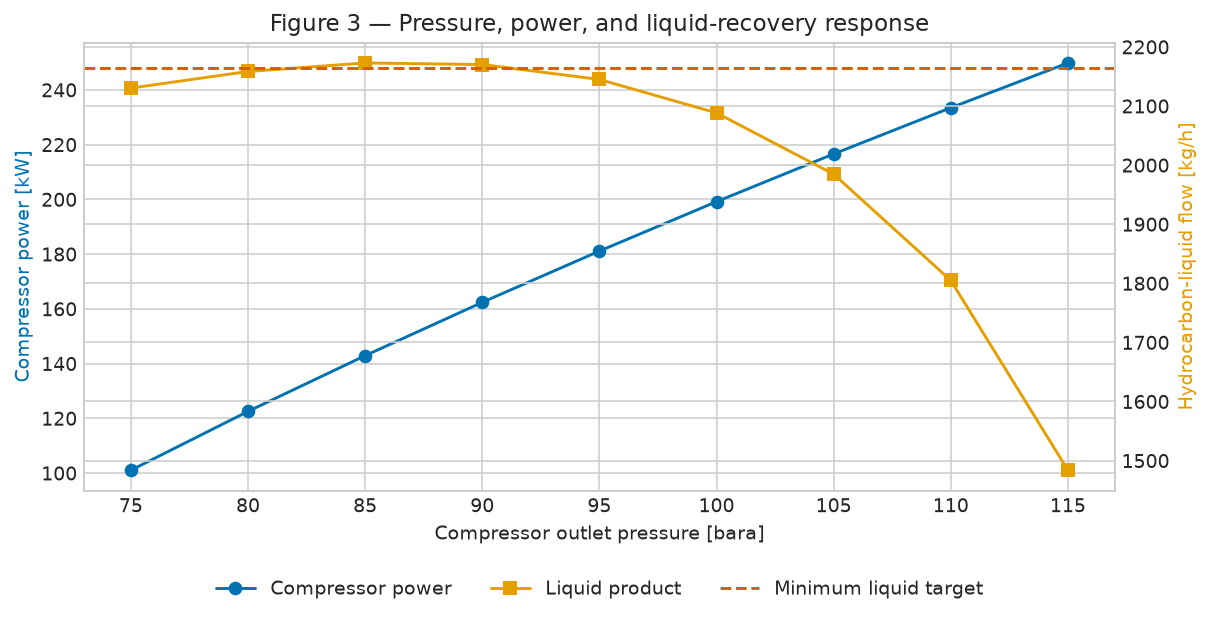

In [17]:
fig, left_axis = plt.subplots(figsize=(9.5, 5.0))
right_axis = left_axis.twinx()

power_line = left_axis.plot(
    pressure_sweep["pressure [bara]"],
    pressure_sweep["power [kW]"],
    marker="o",
    color=COLORS["blue"],
    label="Compressor power",
)
liquid_line = right_axis.plot(
    pressure_sweep["pressure [bara]"],
    pressure_sweep["liquid flow [kg/h]"],
    marker="s",
    color=COLORS["orange"],
    label="Liquid product",
)
right_axis.axhline(
    CASE["minimum_liquid_flow_kg_per_hr"],
    color=COLORS["red"],
    linestyle="--",
    label="Minimum liquid target",
)

left_axis.set_xlabel("Compressor outlet pressure [bara]")
left_axis.set_ylabel("Compressor power [kW]", color=COLORS["blue"])
right_axis.set_ylabel(
    "Hydrocarbon-liquid flow [kg/h]",
    color=COLORS["orange"],
)
left_axis.set_title(
    "Figure 3 — Pressure, power, and liquid-recovery response"
)

all_lines = power_line + liquid_line + [right_axis.lines[-1]]
all_labels = [line.get_label() for line in all_lines]
left_axis.legend(
    all_lines,
    all_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3,
)

fig.subplots_adjust(bottom=0.24)
plt.show()

## Two-dimensional operating-envelope screen

An agent should inspect interacting variables before optimizing. Each grid point uses a fresh
process, so the results are independent of evaluation order. The equivalent energy demand adds
compressor power to the magnitude of cooler duty; it is a screening metric, not a claim about
utility cost or refrigeration coefficient of performance.

In [18]:
def run_independent_case(pressure_bara, cooler_temperature_c):
    scenario_case = dict(CASE)
    scenario_case["compressor_outlet_pressure_bara"] = float(
        pressure_bara
    )
    scenario_case["aftercooler_outlet_temperature_C"] = float(
        cooler_temperature_c
    )
    scenario = build_process(scenario_case)
    scenario_status = json.loads(
        str(scenario["process"].getAutomation().runJson())
    )

    scenario_separator = scenario["separator"]
    scenario_compressor = scenario["compressor"]
    scenario_cooler = scenario["aftercooler"]
    liquid_flow_kg_per_hr = float(
        scenario_separator.getLiquidOutStream().getFlowRate("kg/hr")
    )
    compressor_power_kw = float(
        scenario_compressor.getPower("kW")
    )
    cooler_heat_removed_kw = (
        -float(scenario_cooler.getDuty()) / 1000.0
    )

    return {
        "pressure [bara]": float(pressure_bara),
        "cooler temperature [°C]": float(cooler_temperature_c),
        "compressor power [kW]": compressor_power_kw,
        "heat removed [kW]": cooler_heat_removed_kw,
        "equivalent demand [kW]": (
            compressor_power_kw + cooler_heat_removed_kw
        ),
        "liquid flow [kg/h]": liquid_flow_kg_per_hr,
        "run succeeded": scenario_status["success"],
        "liquid target met": (
            liquid_flow_kg_per_hr
            >= CASE["minimum_liquid_flow_kg_per_hr"]
        ),
    }

In [19]:
grid_pressures_bara = [75.0, 85.0, 95.0, 105.0, 115.0]
grid_temperatures_c = [-5.0, 0.0, 5.0, 10.0]
grid_rows = []

for cooler_temperature_c in grid_temperatures_c:
    for pressure_bara in grid_pressures_bara:
        grid_rows.append(
            run_independent_case(
                pressure_bara,
                cooler_temperature_c,
            )
        )

operating_grid = pd.DataFrame(grid_rows)
display(operating_grid)

,pressure [bara],cooler temperature [°C],compressor power [kW],heat removed [kW],equivalent demand [kW],liquid flow [kg/h],run succeeded,liquid target met
0,75.0,-5.0,101.018101,499.879657,600.897757,2683.977111,True,True
1,85.0,-5.0,142.884718,585.241010,728.125728,2782.540608,True,True
2,95.0,-5.0,181.095797,665.500381,846.596178,2819.159518,True,True
3,105.0,-5.0,216.584696,741.431389,958.016085,2712.814108,True,True
4,115.0,-5.0,249.827217,813.032276,1062.859493,2032.170383,True,False
5,75.0,0.0,101.018101,444.419478,545.437579,2401.680973,True,True
6,85.0,0.0,142.884718,528.029082,670.913800,2469.483017,True,True
7,95.0,0.0,181.095797,606.437127,787.532924,2470.018401,True,True
8,105.0,0.0,216.584696,680.538179,897.122875,2332.905427,True,True
9,115.0,0.0,249.827217,750.527518,1000.354735,1775.720759,True,False


## Figure 4 — operating envelope

The heatmap shows liquid recovery, while white circles identify cases that satisfy the target.
The agent can use this map to define defensible bounds before starting a narrower optimizer.

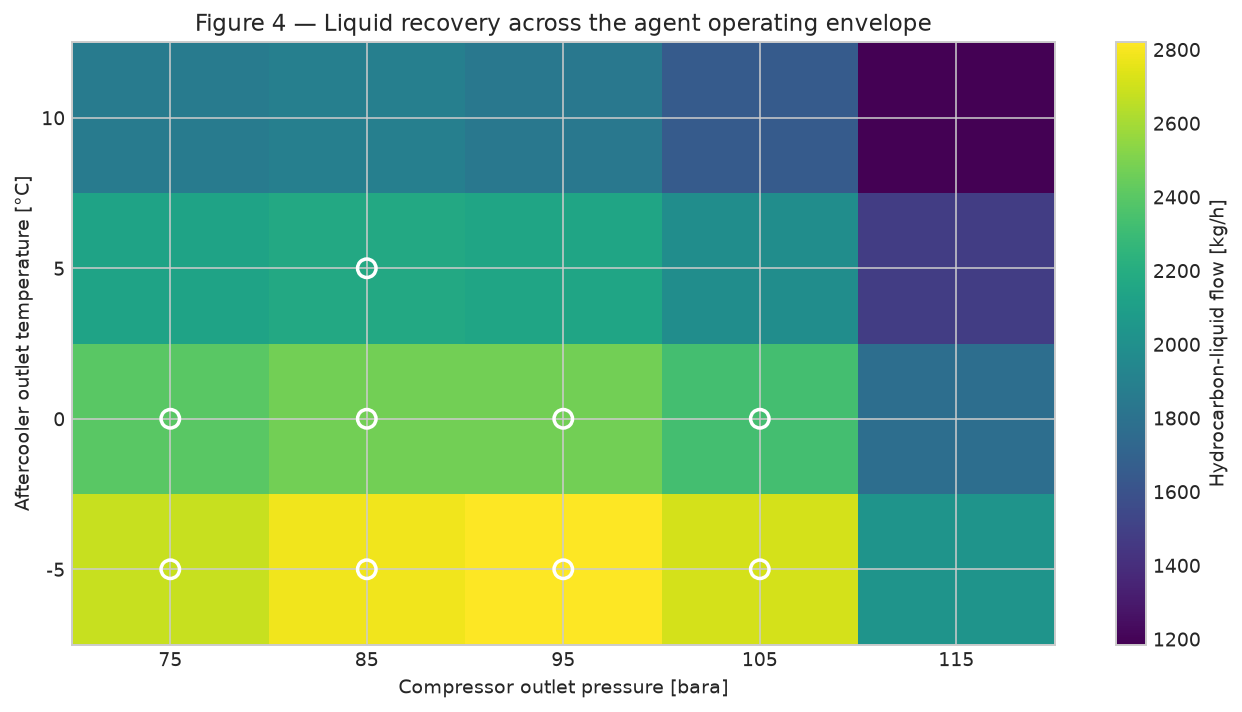

In [20]:
liquid_pivot = operating_grid.pivot(
    index="cooler temperature [°C]",
    columns="pressure [bara]",
    values="liquid flow [kg/h]",
)
target_pivot = operating_grid.pivot(
    index="cooler temperature [°C]",
    columns="pressure [bara]",
    values="liquid target met",
)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
image = ax.imshow(
    liquid_pivot.to_numpy(),
    origin="lower",
    aspect="auto",
    cmap="viridis",
)

ax.set_xticks(range(len(liquid_pivot.columns)))
ax.set_xticklabels([f"{value:.0f}" for value in liquid_pivot.columns])
ax.set_yticks(range(len(liquid_pivot.index)))
ax.set_yticklabels([f"{value:.0f}" for value in liquid_pivot.index])
ax.set_xlabel("Compressor outlet pressure [bara]")
ax.set_ylabel("Aftercooler outlet temperature [°C]")
ax.set_title(
    "Figure 4 — Liquid recovery across the agent operating envelope"
)

for row_index in range(target_pivot.shape[0]):
    for column_index in range(target_pivot.shape[1]):
        if target_pivot.iloc[row_index, column_index]:
            ax.scatter(
                column_index,
                row_index,
                marker="o",
                facecolors="none",
                edgecolors="white",
                linewidths=1.8,
                s=90,
            )

fig.colorbar(
    image,
    ax=ax,
    label="Hydrocarbon-liquid flow [kg/h]",
)
fig.tight_layout()
plt.show()

Colder aftercooling generally increases condensation. Pressure effects are not monotonic over the
whole grid because phase equilibrium, density, and mixture critical behavior interact. The
operating map therefore supports constraint selection but does not replace equipment or
flow-assurance design.

## Reject a malformed candidate safely

The following deliberately invalid address is evaluated without an exception. The result must be
infeasible and must explain the rejected setpoint. This is a limiting-case software check for an
agent loop.

In [21]:
invalid_setpoints = LinkedHashMap()
invalid_setpoints.put(
    "Unknown compressor.outletPressure",
    90.0,
)
invalid_readbacks = ArrayList()
invalid_readbacks.add("Export compressor.power")

invalid_evaluation = json.loads(
    str(
        automation.evaluate(
            invalid_setpoints,
            "bara",
            invalid_readbacks,
            "kW",
            30,
            5.0e-3,
        )
    )
)

display(pd.json_normalize(invalid_evaluation))

,schemaVersion,runSucceeded,converged,failedUnitName,failedUnitError,feasible,setpointsRejected.Unknown compressor.outletPressure,readbacks.Export compressor.power
0,1.0,True,True,None,None,False,Unit not found: Unknown compressor. Did you me...,249.827217


## Native agentic optimization

`AgenticProcessOptimizer` performs a deterministic bounded Nelder-Mead search through the same
automation facade. The decision variable is compressor outlet pressure from 75 to 115 bara.
The objective is minimum compressor power, subject to at least 2165 kg/h hydrocarbon liquid at
the fixed 5°C aftercooler outlet.

The optimizer logs every candidate, objective, penalty, feasibility flag, and readback. It is a
screening optimizer; the selected pressure should still be rounded and checked against compressor
maps and process constraints.

In [22]:
optimizer_case = build_process(CASE)
optimizer_automation = optimizer_case["process"].getAutomation()
optimizer_automation.runJson()

optimizer = optimizer_automation.newOptimizer()
optimizer.addVariable(
    "Export compressor.outletPressure",
    CASE["pressure_bounds_bara"][0],
    CASE["pressure_bounds_bara"][1],
    "bara",
)
optimizer.minimize(
    "Export compressor.power",
    "kW",
)
optimizer.addConstraintGreaterOrEqual(
    "Cold separator.liquidOutStream.flowRate",
    CASE["minimum_liquid_flow_kg_per_hr"],
    "kg/hr",
    100.0,
)
optimizer.setSeed(42)
optimizer.setMaxEvaluations(30)
optimizer.setConvergenceTolerance(1.0e-4)

optimization_result = json.loads(
    str(optimizer.optimizeToJson())
)
optimizer_readiness = json.loads(
    str(optimizer.getReadinessJson())
)

optimization_summary = {
    key: value
    for key, value in optimization_result.items()
    if key != "trajectory"
}

print(json.dumps(optimization_summary, indent=2))
display(pd.json_normalize(optimizer_readiness))

{
  "schemaVersion": "1.0",
  "success": true,
  "feasible": true,
  "message": "converged to a feasible optimum",
  "evaluations": 30,
  "bestObjective": 129.6394379899587,
  "bestScore": 129.6394379899587,
  "bestSetpoints": {
    "Export compressor.outletPressure": 81.71875
  },
  "bestReadbacks": {
    "Cold separator.liquidOutStream.flowRate": 2165.0272855538265,
    "Export compressor.power": 129.6394379899587
  }
}


,schemaVersion,optimizer,algorithm,capabilities,recommendedUse
0,1.0,AgenticProcessOptimizer,bounded Nelder-Mead simplex with deterministic...,"[{'capability': 'never_throws', 'level': 'full...","closed-loop setpoint optimization, RL environm..."


In [23]:
optimization_trajectory = pd.DataFrame(
    [
        {
            "evaluation": trial["index"],
            "pressure [bara]": trial["setpoints"][
                "Export compressor.outletPressure"
            ],
            "power [kW]": trial["objective"],
            "liquid flow [kg/h]": trial["readbacks"][
                "Cold separator.liquidOutStream.flowRate"
            ],
            "penalty [-]": trial["penalty"],
            "feasible": trial["feasible"],
        }
        for trial in optimization_result["trajectory"]
    ]
)

display(optimization_trajectory)

,evaluation,pressure [bara],power [kW],liquid flow [kg/h],penalty [-],feasible
0,1,95.000000,181.095797,2144.936740,4.025344e+04,False
1,2,104.102547,213.497596,2007.792052,2.471434e+06,False
2,3,102.328939,207.342499,2047.201160,1.387657e+06,False
3,4,97.000000,188.394079,2126.717002,1.465588e+05,False
4,5,93.000000,173.689165,2158.192756,4.633857e+03,False
5,6,97.000000,188.394079,2126.717002,1.465588e+05,False
6,7,91.000000,166.169687,2167.129101,0.000000e+00,True
7,8,95.000000,181.095797,2144.936740,4.025344e+04,False
8,9,89.000000,158.532578,2172.270124,0.000000e+00,True
9,10,93.000000,173.689165,2158.192756,4.633857e+03,False


## Figure 5 — replayable optimization trajectory

Feasible and penalized candidates are shown separately. The target line makes the constraint
boundary visible, while the power curve shows the cost of moving to higher pressure.

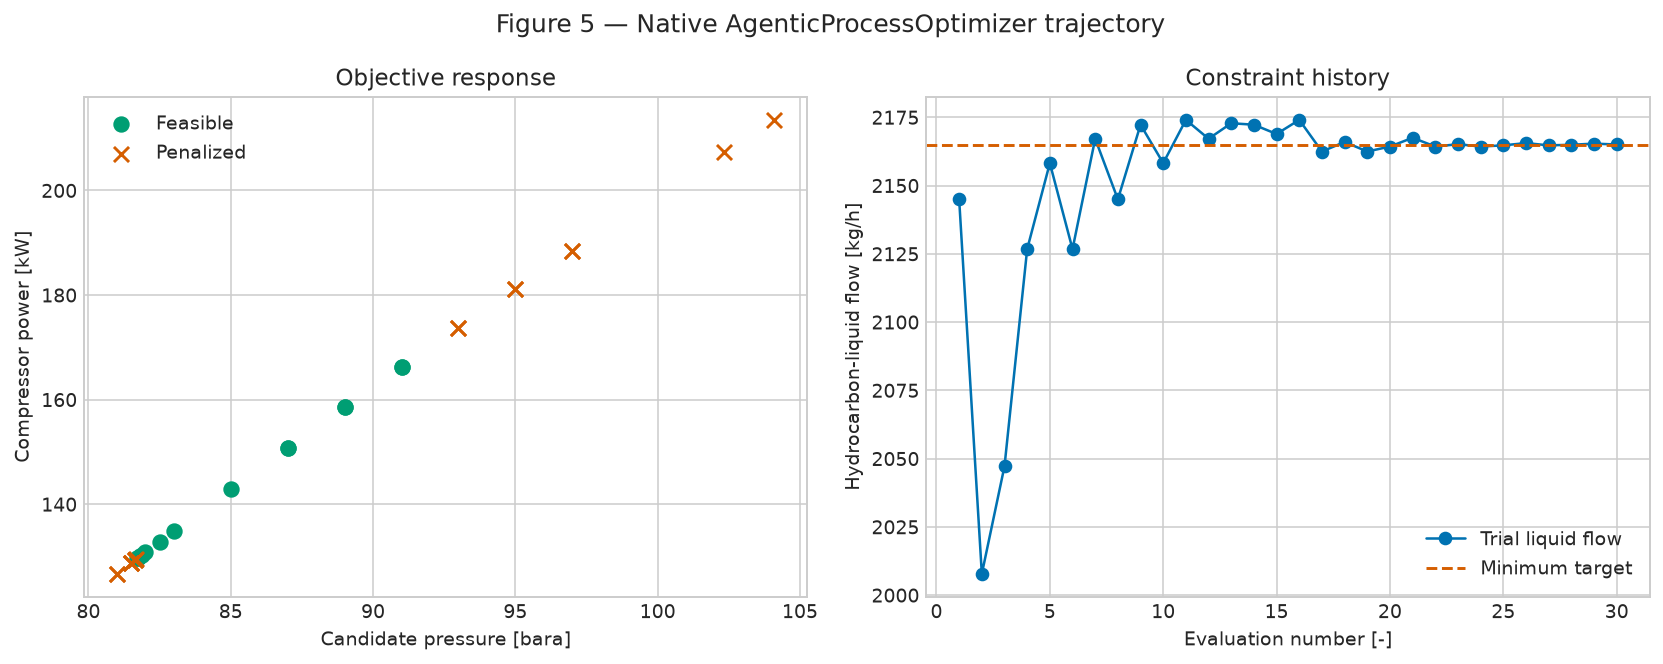

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

feasible_trials = optimization_trajectory[
    optimization_trajectory["feasible"]
]
infeasible_trials = optimization_trajectory[
    ~optimization_trajectory["feasible"]
]

axes[0].scatter(
    feasible_trials["pressure [bara]"],
    feasible_trials["power [kW]"],
    color=COLORS["green"],
    label="Feasible",
    s=55,
)
axes[0].scatter(
    infeasible_trials["pressure [bara]"],
    infeasible_trials["power [kW]"],
    color=COLORS["red"],
    marker="x",
    label="Penalized",
    s=60,
)
axes[0].set_xlabel("Candidate pressure [bara]")
axes[0].set_ylabel("Compressor power [kW]")
axes[0].set_title("Objective response")
axes[0].legend()

axes[1].plot(
    optimization_trajectory["evaluation"],
    optimization_trajectory["liquid flow [kg/h]"],
    color=COLORS["blue"],
    marker="o",
    linewidth=1.3,
    label="Trial liquid flow",
)
axes[1].axhline(
    CASE["minimum_liquid_flow_kg_per_hr"],
    color=COLORS["red"],
    linestyle="--",
    label="Minimum target",
)
axes[1].set_xlabel("Evaluation number [-]")
axes[1].set_ylabel("Hydrocarbon-liquid flow [kg/h]")
axes[1].set_title("Constraint history")
axes[1].legend()

fig.suptitle(
    "Figure 5 — Native AgenticProcessOptimizer trajectory",
    fontsize=13,
)
fig.tight_layout()
plt.show()

The optimizer approaches the lower-pressure boundary that still meets the liquid target. Trials
slightly below the boundary receive a penalty rather than crashing the search. Replaying the
stored trajectory is essential for auditability and model-governance review.

## Independent final application check

The best setpoint is applied to a newly built process rather than trusting optimizer state. This
is the reusable end-to-end application: configure the case, build the model, run, retrieve KPIs,
check the specification, and emit a governed result object.

In [25]:
best_pressure_bara = float(
    optimization_result["bestSetpoints"][
        "Export compressor.outletPressure"
    ]
)
selected_case = dict(CASE)
selected_case["compressor_outlet_pressure_bara"] = best_pressure_bara
selected = build_process(selected_case)
selected_status = json.loads(
    str(selected["process"].getAutomation().runJson())
)

selected_power_kw = float(
    selected["compressor"].getPower("kW")
)
selected_liquid_flow_kg_per_hr = float(
    selected["separator"].getLiquidOutStream().getFlowRate("kg/hr")
)
selected_mass_residual_kg_per_hr = float(
    selected["separator"].getGasOutStream().getFlowRate("kg/hr")
    + selected["separator"].getLiquidOutStream().getFlowRate("kg/hr")
    - selected["feed"].getFlowRate("kg/hr")
)

final_agent_result = {
    "schema_version": "1.0",
    "case_name": CASE["name"],
    "selected_setpoints": {
        "compressor_outlet_pressure_bara": best_pressure_bara,
        "aftercooler_outlet_temperature_C": (
            CASE["aftercooler_outlet_temperature_C"]
        ),
    },
    "key_results": {
        "compressor_power_kW": selected_power_kw,
        "liquid_product_kg_per_hr": (
            selected_liquid_flow_kg_per_hr
        ),
    },
    "validation": {
        "run_succeeded": selected_status["success"],
        "liquid_target_met": (
            selected_liquid_flow_kg_per_hr
            >= CASE["minimum_liquid_flow_kg_per_hr"]
        ),
        "mass_residual_kg_per_hr": (
            selected_mass_residual_kg_per_hr
        ),
    },
    "provenance": baseline_results["provenance"],
}

print(json.dumps(final_agent_result, indent=2))

{
  "schema_version": "1.0",
  "case_name": "rich-gas conditioning",
  "selected_setpoints": {
    "compressor_outlet_pressure_bara": 81.71875,
    "aftercooler_outlet_temperature_C": 5.0
  },
  "key_results": {
    "compressor_power_kW": 129.6394379899587,
    "liquid_product_kg_per_hr": 2165.0272855538265
  },
  "validation": {
    "run_succeeded": true,
    "liquid_target_met": true,
    "mass_residual_kg_per_hr": -1.8189894035458565e-12
  },
  "provenance": {
    "neqsim_version": "3.16.0",
    "python_version": "3.12.13",
    "java_version": "openjdk version \"17.0.19\" 2026-04-21",
    "thermodynamic_model": "SRK",
    "mixing_rule": "classic"
  }
}


## Final acceptance checks

The checks cover JSON contracts, physical balances, safe failure behavior, scenario trends,
independent execution, and optimizer reproducibility. A notebook run fails immediately if any
acceptance criterion is violated.

In [26]:
assert math.isclose(composition_sum, 1.0, abs_tol=1e-12)
assert baseline_run_status["success"]
assert baseline_run_status["completed"]
assert len(unit_names) == 4
assert len(variable_catalog) >= 40
assert adjustable_parameters["count"] >= 6
assert safe_read["status"] in {"success", "auto_corrected"}
assert math.isfinite(baseline_results["key_results"]["compressor_power_kW"])
assert baseline_results["key_results"]["compressor_power_kW"] > 0.0
assert baseline_results["key_results"]["aftercooler_duty_kW"] < 0.0
assert abs(mass_residual_kg_per_hr) < 1.0e-6
assert maximum_component_residual_mol_per_s < 1.0e-9
assert abs(compressor_energy_residual_w) < 1.0e-6
assert abs(cooler_energy_residual_w) < 1.0e-6
assert pressure_sweep["feasible run"].all()
assert pressure_sweep["power [kW]"].is_monotonic_increasing
assert operating_grid["run succeeded"].all()
assert operating_grid["liquid target met"].any()
assert not invalid_evaluation["feasible"]
assert len(invalid_evaluation["setpointsRejected"]) == 1
assert optimization_result["success"]
assert optimization_result["feasible"]
assert optimization_result["evaluations"] >= 20
assert selected_status["success"]
assert selected_liquid_flow_kg_per_hr >= (
    CASE["minimum_liquid_flow_kg_per_hr"]
)
assert abs(selected_mass_residual_kg_per_hr) < 1.0e-6
assert math.isclose(
    selected_power_kw,
    optimization_result["bestObjective"],
    rel_tol=1.0e-10,
)

print("All 26 agentic-process engineering checks passed.")

All 26 agentic-process engineering checks passed.


## Summary and practical limitations

This notebook preserved the original fluid builder, structured case, compressor process, and
JSON result while adding the current NeqSim automation surface. The final application discovers
variables, applies safe writes, runs gated trials, validates balances, screens two interacting
inputs, rejects a malformed candidate, performs native bounded optimization, and independently
rechecks the selected case.

The optimizer result is not a design recommendation. Real deployment needs authenticated tool
boundaries, change approval, equipment curves, anti-surge constraints, pressure-drop models,
flow-assurance checks, uncertainty analysis, alarm handling, persistence, and independent human
review. Never let a language model bypass plant safety systems or write directly to control
equipment.

### Troubleshooting

- If a variable address fails, call `getUnitList()` and `getVariableList()` before using safe
  accessors.
- If a trial is infeasible, inspect `setpointsRejected`, `failedUnitName`, and `readbackErrors`.
- If phase results change sharply, rebuild a fresh case and inspect composition, units, and phase
  count.
- If an optimizer reaches a bound, widen it only after checking engineering and equipment limits.

### Further exercises

1. Add compressor-map or maximum-discharge-temperature constraints.
2. Use a second decision variable for cooler outlet temperature with a utility-cost objective.
3. Save the trajectory to a governed data store and replay every accepted candidate.
4. Replace SRK with Peng-Robinson and compare the feasible region.
5. Add measurement uncertainty and require robust rather than nominal feasibility.

### Authoritative NeqSim references

- [Process automation API](https://equinor.github.io/neqsim/simulation/process_automation.html)
- [Process simulation guide](https://equinor.github.io/neqsim/process/)
- [NeqSim thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [Current ProcessAutomation source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/automation/ProcessAutomation.java)
- [Current AgenticProcessOptimizer source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/automation/AgenticProcessOptimizer.java)